#Extracción

Importación de los datos desde la api para poder manejar el dataset

In [1]:
import pandas as pd
import requests

In [2]:
url="https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"
respuesta = requests.get(url)
datos = respuesta.json()
datosdf = pd.json_normalize(datos)
datosdf.head(2)

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4


In [3]:
datosdf.sample(5)

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
1415,2038-YSEZE,No,Female,0,No,No,29,Yes,Yes,DSL,...,Yes,No,Yes,No,No,Month-to-month,No,Mailed check,67.45,1801.1
3544,4884-LEVMQ,No,Male,0,Yes,No,39,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790
2097,2954-PIBKO,No,Female,0,Yes,Yes,69,Yes,Yes,DSL,...,No,Yes,Yes,No,No,Two year,Yes,Credit card (automatic),64.15,4254.1
620,0880-TKATG,Yes,Male,0,Yes,Yes,4,Yes,Yes,Fiber optic,...,No,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,101.15,385.9
4035,5520-FVEWJ,Yes,Female,0,Yes,Yes,12,Yes,Yes,Fiber optic,...,Yes,Yes,No,No,No,Month-to-month,Yes,Electronic check,84.50,916.9


#Transformación

In [4]:
columnas = list(datosdf.columns)
columnas

['customerID',
 'Churn',
 'customer.gender',
 'customer.SeniorCitizen',
 'customer.Partner',
 'customer.Dependents',
 'customer.tenure',
 'phone.PhoneService',
 'phone.MultipleLines',
 'internet.InternetService',
 'internet.OnlineSecurity',
 'internet.OnlineBackup',
 'internet.DeviceProtection',
 'internet.TechSupport',
 'internet.StreamingTV',
 'internet.StreamingMovies',
 'account.Contract',
 'account.PaperlessBilling',
 'account.PaymentMethod',
 'account.Charges.Monthly',
 'account.Charges.Total']

customerID, Churn, customer.Tenure, account.Contract, Charges.PaymentMethod, account.Charges.Monthly,account.Charges.Total

In [5]:
datosdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

Verificación de posibles problemas dentro de los datos

In [6]:
#datos nulos
print(datosdf.isnull().sum())


customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64


In [7]:
#datos ausentes
print(datosdf.isin([""," "]).sum())

customerID                     0
Churn                        224
customer.gender                0
customer.SeniorCitizen         0
customer.Partner               0
customer.Dependents            0
customer.tenure                0
phone.PhoneService             0
phone.MultipleLines            0
internet.InternetService       0
internet.OnlineSecurity        0
internet.OnlineBackup          0
internet.DeviceProtection      0
internet.TechSupport           0
internet.StreamingTV           0
internet.StreamingMovies       0
account.Contract               0
account.PaperlessBilling       0
account.PaymentMethod          0
account.Charges.Monthly        0
account.Charges.Total         11
dtype: int64


In [8]:
datosdf["Churn"] = datosdf["Churn"].replace("","Unknown")

In [9]:
print(datosdf['Churn'].isin([""," "]).sum())

0


In [10]:
total0 = datosdf.loc[datosdf['account.Charges.Total'] == " "]
total0

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
975,1371-DWPAZ,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,
1775,2520-SGTTA,No,Female,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,
1955,2775-SEFEE,No,Male,0,No,Yes,0,Yes,Yes,DSL,...,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,
2075,2923-ARZLG,No,Male,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,
2232,3115-CZMZD,No,Male,0,No,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,
2308,3213-VVOLG,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,
2930,4075-WKNIU,No,Female,0,Yes,Yes,0,Yes,Yes,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,
3134,4367-NUYAO,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,
3203,4472-LVYGI,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,
4169,5709-LVOEQ,No,Female,0,Yes,Yes,0,Yes,No,DSL,...,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,


In [11]:
datosdf['account.Charges.Total'] = datosdf['account.Charges.Total'].replace(" ","0")

In [12]:
datosdf["account.Charges.Total"].loc[datosdf['account.Charges.Total']=="0"]

,account.Charges.Total
975,0
1775,0
1955,0
2075,0
2232,0
2308,0
2930,0
3134,0
3203,0
4169,0


In [13]:
print(datosdf.isin([""," "]).sum())

customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64


In [14]:
datosdf['customer.SeniorCitizen'] = datosdf['customer.SeniorCitizen'].map({1: "Yes",0:"No"})

In [15]:
#datos duplicados
print(datosdf.duplicated().sum())

0


In [16]:
datosdf.sample(1)

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
3184,4446-BZKHU,Yes,Male,No,Yes,No,61,Yes,Yes,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,105.55,6281.45


In [17]:
datosdf['account.Charges.Total'] = datosdf['account.Charges.Total'].astype(float)

In [18]:
#tipos de datos
print(datosdf.dtypes)

customerID                    object
Churn                         object
customer.gender               object
customer.SeniorCitizen        object
customer.Partner              object
customer.Dependents           object
customer.tenure                int64
phone.PhoneService            object
phone.MultipleLines           object
internet.InternetService      object
internet.OnlineSecurity       object
internet.OnlineBackup         object
internet.DeviceProtection     object
internet.TechSupport          object
internet.StreamingTV          object
internet.StreamingMovies      object
account.Contract              object
account.PaperlessBilling      object
account.PaymentMethod         object
account.Charges.Monthly      float64
account.Charges.Total        float64
dtype: object


In [19]:
#inconsistencias en las categorías
for col in datosdf.columns:
  if col != "customerID":
    print(f"Columna: {col}:{datosdf[col].unique()}")

Columna: Churn:['No' 'Yes' 'Unknown']
Columna: customer.gender:['Female' 'Male']
Columna: customer.SeniorCitizen:['No' 'Yes']
Columna: customer.Partner:['Yes' 'No']
Columna: customer.Dependents:['Yes' 'No']
Columna: customer.tenure:[ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]
Columna: phone.PhoneService:['Yes' 'No']
Columna: phone.MultipleLines:['No' 'Yes' 'No phone service']
Columna: internet.InternetService:['DSL' 'Fiber optic' 'No']
Columna: internet.OnlineSecurity:['No' 'Yes' 'No internet service']
Columna: internet.OnlineBackup:['Yes' 'No' 'No internet service']
Columna: internet.DeviceProtection:['No' 'Yes' 'No internet service']
Columna: internet.TechSupport:['Yes' 'No' 'No internet service']
Columna: internet.StreamingTV:['Yes' 'No' 'No internet service']
Columna: internet.StreamingMovies:['No' 'Yes' '

In [20]:
datosdf["Cuentas_Diarias"]=datosdf['account.Charges.Monthly']/30
datosdf.sample(1)

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
2816,3902-MIVLE,No,Male,No,Yes,Yes,63,Yes,Yes,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,75.7,4676.7,2.523333


In [21]:
nuevosNombres = {
    'customerID': 'ID',
    'customer.gender': 'Genero',
    'customer.SeniorCitizen': 'AdultoMayor',
    'customer.Partner': 'Pareja',
    'customer.Dependents': 'Dependientes',
    'customer.tenure': 'MesesCliente',
    'phone.PhoneService': 'ServicioTelefono',
    'phone.MultipleLines': 'MultiplesLineas',
    'internet.InternetService': 'TipoInternet',
    'internet.OnlineSecurity': 'SeguridadOnline',
    'internet.OnlineBackup': 'RespaldoOnline',
    'internet.DeviceProtection': 'ProteccionDispositivo',
    'internet.TechSupport': 'SoporteTecnico',
    'internet.StreamingTV': 'StreamingTV',
    'internet.StreamingMovies': 'StreamingPeliculas',
    'account.Contract': 'Contrato',
    'account.PaperlessBilling': 'FacturaDigital',
    'account.PaymentMethod': 'MetodoPago',
    'account.Charges.Monthly': 'GastoMensual',
    'account.Charges.Total': 'GastoTotal'
}

datosdf.rename(columns=nuevosNombres,inplace=True)
datosdf.sample(1)

,ID,Churn,Genero,AdultoMayor,Pareja,Dependientes,MesesCliente,ServicioTelefono,MultiplesLineas,TipoInternet,...,ProteccionDispositivo,SoporteTecnico,StreamingTV,StreamingPeliculas,Contrato,FacturaDigital,MetodoPago,GastoMensual,GastoTotal,Cuentas_Diarias
2980,4134-BSXLX,No,Male,No,Yes,No,28,Yes,No,DSL,...,No,Yes,No,No,Month-to-month,No,Mailed check,60.9,1785.65,2.03


#Carga y análisis

In [22]:
datosdf.describe()

,MesesCliente,GastoMensual,GastoTotal,Cuentas_Diarias
count,7267.000000,7267.000000,7267.000000,7267.000000
mean,32.346498,64.720098,2277.182035,2.157337
std,24.571773,30.129572,2268.648587,1.004319
min,0.000000,18.250000,0.000000,0.608333
25%,9.000000,35.425000,396.200000,1.180833
50%,29.000000,70.300000,1389.200000,2.343333
75%,55.000000,89.875000,3778.525000,2.995833
max,72.000000,118.750000,8684.800000,3.958333


In [23]:
import matplotlib.pyplot as plt

In [25]:
promedioChurn = datosdf['Churn'].value_counts(normalize=True)*100
promedioChurn

,proportion
Churn,
No,71.198569
Yes,25.719004
Unknown,3.082427


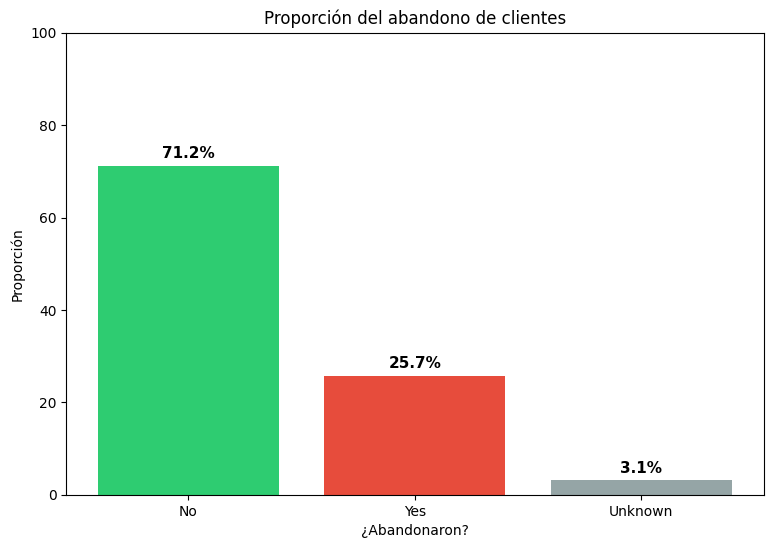

In [26]:
colores= ['#2ecc71', '#e74c3c', '#95a5a6']
fig, ax = plt.subplots(figsize=(9,6))
ax.bar(promedioChurn.index,promedioChurn.values,color=colores)
ax.set_title("Proporción del abandono de clientes")
ax.set_xlabel("¿Abandonaron?")
ax.set_ylabel("Proporción")
ax.set_ylim(0,100)
for i, j in enumerate(promedioChurn):
  ax.text(i,j+1,f"{j:.1f}%",ha="center",va="bottom",fontsize=11,fontweight="bold")
plt.show()

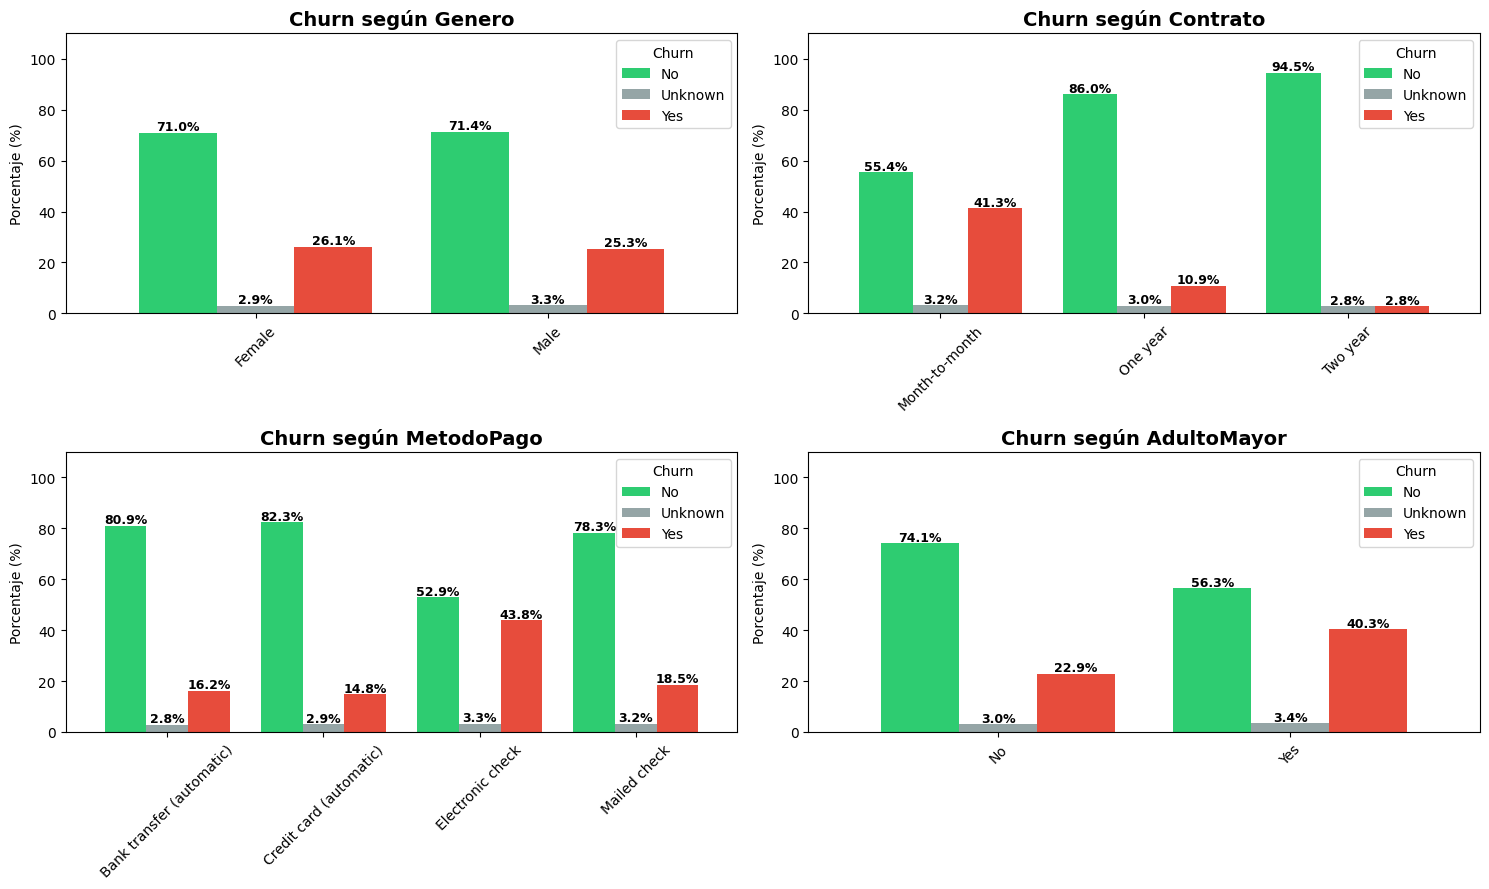

In [27]:
fig,ax=plt.subplots(2,2,figsize=(15,9))

variables = ["Genero","Contrato","MetodoPago","AdultoMayor"]
ejes = ax.flatten()
colores={'No': '#2ecc71', 'Yes': '#e74c3c', 'Unknown': '#95a5a6'}

for i, var in enumerate(variables):
  tablaProb = pd.crosstab(datosdf[var],datosdf["Churn"],normalize="index")*100
  tablaProb.plot(kind="bar",ax=ejes[i],color=[colores[c] for c in tablaProb.columns],width=0.8)
  ejes[i].set_title(f"Churn según {var}",fontsize=14,fontweight="bold")
  ejes[i].set_ylabel("Porcentaje (%)")
  ejes[i].set_xlabel("")
  ejes[i].set_ylim(0,110)
  ejes[i].legend(title="Churn",loc="upper right")
  ejes[i].tick_params(axis="x",rotation=45)

  for p in ejes[i].patches:
    height=p.get_height()
    if height>0:
      ejes[i].text(p.get_x()+p.get_width()/2.,height+1,f"{height:.1f}%",ha="center",fontsize=9,fontweight="bold")

plt.tight_layout()
plt.show()

/tmp/ipykernel_221/4126560925.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Churn",y="MesesCliente",data=datosdf,ax=ax[0,0],palette=colores)
/tmp/ipykernel_221/4126560925.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Churn",y="GastoMensual",data=datosdf,ax=ax[0,1],palette=colores)
/tmp/ipykernel_221/4126560925.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Churn",y="GastoTotal",data=datosdf,ax=ax[1,0],palette=colores)


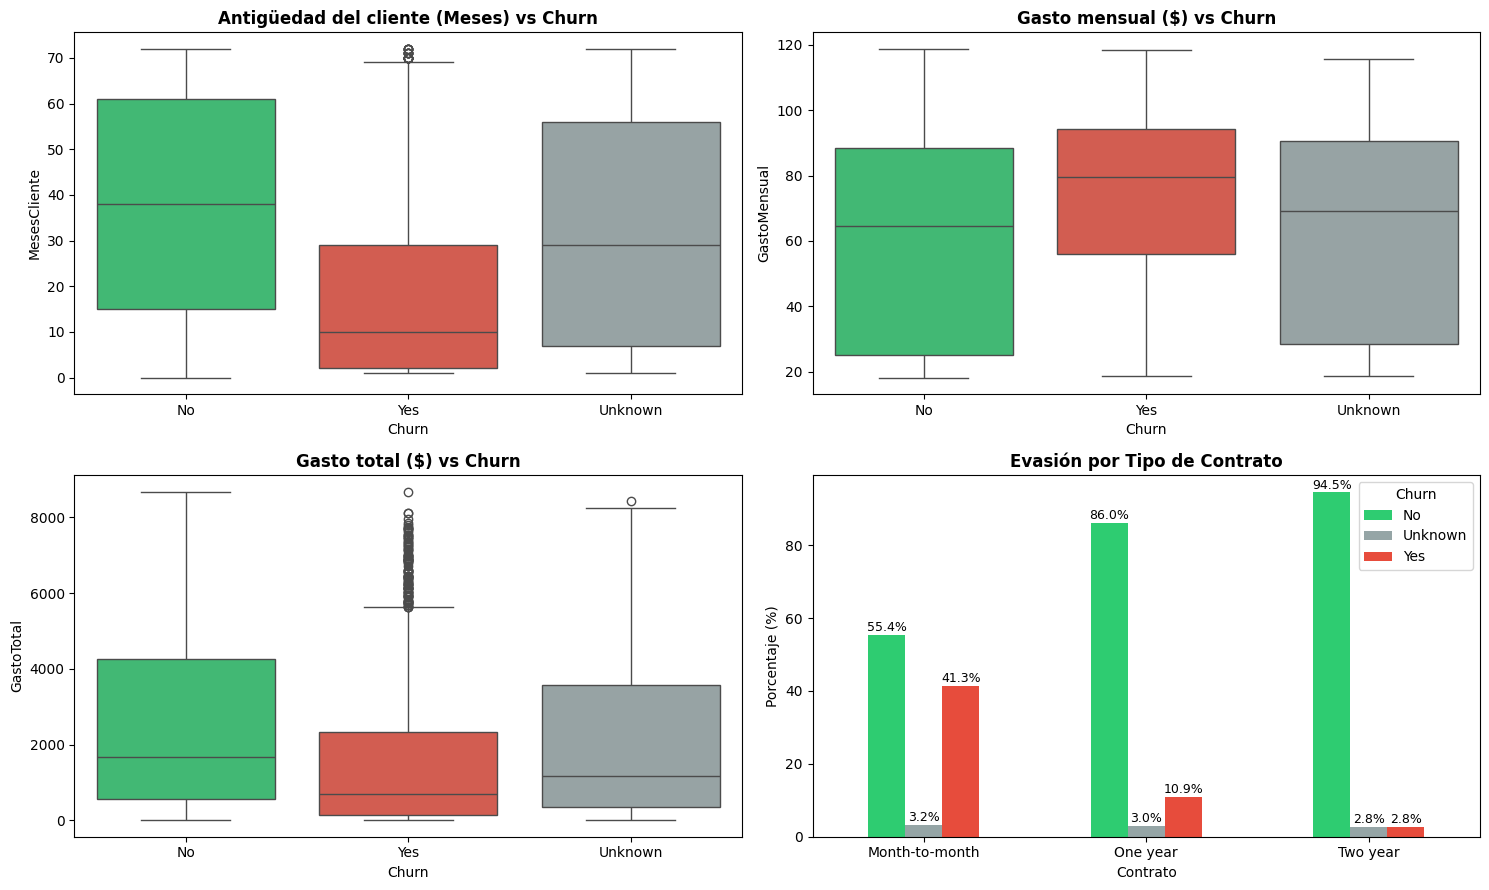

In [28]:
import seaborn as sns
fig,ax=plt.subplots(2,2,figsize=(15,9))

colores={'No': '#2ecc71', 'Yes': '#e74c3c', 'Unknown': '#95a5a6'}

sns.boxplot(x="Churn",y="MesesCliente",data=datosdf,ax=ax[0,0],palette=colores)
ax[0,0].set_title("Antigüedad del cliente (Meses) vs Churn",fontsize=12,fontweight="bold")

sns.boxplot(x="Churn",y="GastoMensual",data=datosdf,ax=ax[0,1],palette=colores)
ax[0,1].set_title("Gasto mensual ($) vs Churn",fontsize=12,fontweight="bold")

sns.boxplot(x="Churn",y="GastoTotal",data=datosdf,ax=ax[1,0],palette=colores)
ax[1,0].set_title("Gasto total ($) vs Churn",fontsize=12,fontweight="bold")

tabla_contrato = pd.crosstab(datosdf['Contrato'], datosdf['Churn'], normalize='index') * 100
tabla_contrato.plot(kind='bar', ax=ax[1, 1], color=[colores[c] for c in tabla_contrato.columns])
ax[1, 1].set_title('Evasión por Tipo de Contrato', fontsize=12, fontweight='bold')
ax[1, 1].set_ylabel('Porcentaje (%)')
ax[1, 1].tick_params(axis='x', rotation=0)

for p in ax[1, 1].patches:
    h = p.get_height()
    if h > 0:
        ax[1, 1].text(p.get_x() + p.get_width()/2., h + 1, f'{h:.1f}%', ha="center", fontsize=9)
plt.tight_layout()
plt.show()

#Informe final

El objetivo de este análisis fue el de realizar una visualización y un entendimiento de las razones por las que los clientes cancelaban su contrato con la empresa (churn), acción que, gracias a los métodos utilizados, comparamos en base a conceptos como la edad, el tipo y/o cantidad del pago, y el tipo de contrato

Se analizó el dataset entero para encontrar problemas con los datos vomo valores nulos, registros vacíos, registros duplicados o inconsistencias en las columnas.
El principal problema en este paso fue encontrar una gran cantidad de valores vacíos en los registros de la columna churn, los cuales, en lugar de eliminar dichos clientes, los tratamos como una nueva columna "unknown" y se demostró en las gráficas que estos datos eran mínimos en comparación.


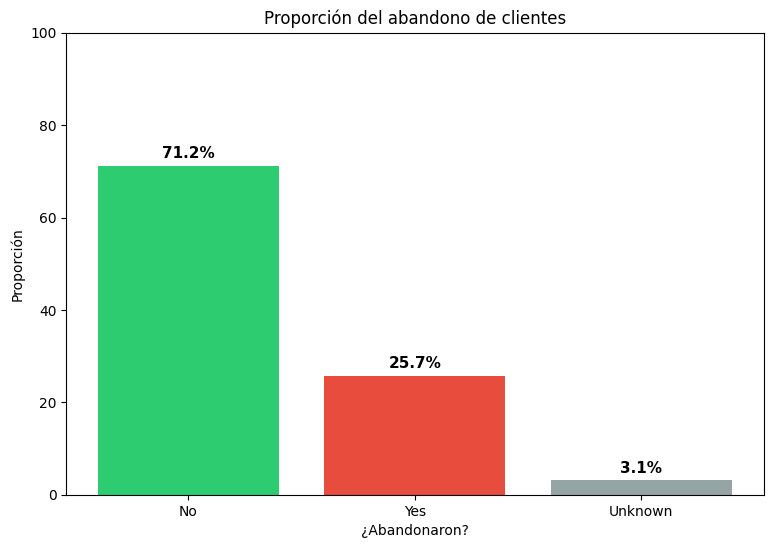

Aunque se analizaron varios parámetros dentro de esta actividad, los datos no mienten, y menos cuando esos datos pueden visualizarse de forma gráfica.
El principal motivo de la evasión de clientes llegó de la mano del tipo de contrato establecido con los mismos, siendo alrededor del 40% de los clientes con el contrato mes-a-mes los que terminaban por tomar la decisión de irse, contra apenas un 10% y un 2% (aproximadamente) de los clientes con un contrato de uno y dos años respectivamente.



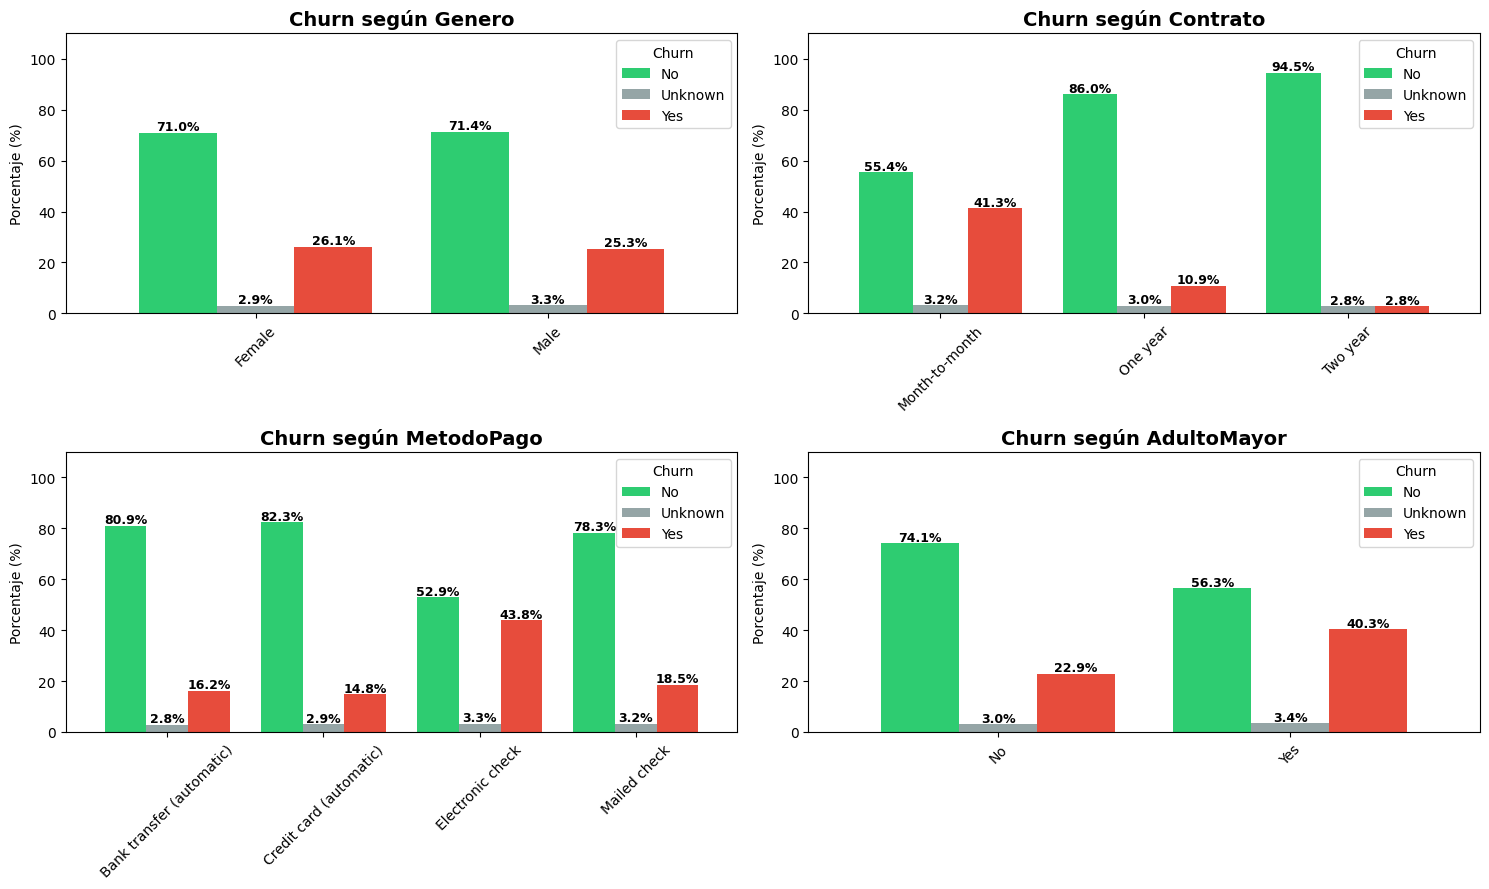

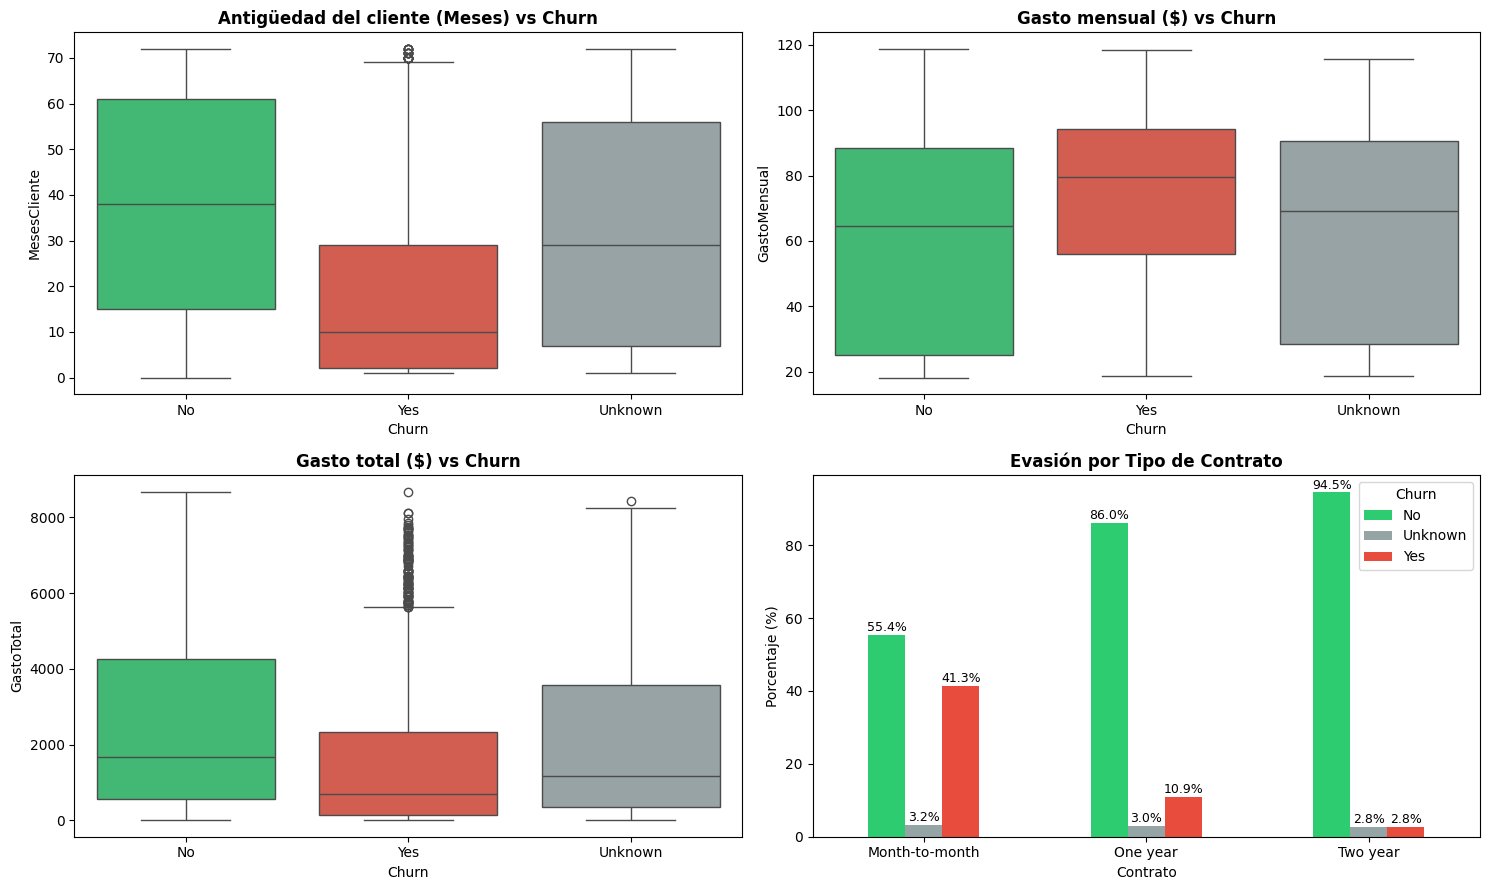

Una clara recomendación en base al análisis realizado, es la de modificar los términos y condiciones del contrato mes-a-mes, como por ejemplo añadiendo cláusulas que deriven a una penalización por corte del contrato, o buscar ofrecer algo distinto para animar a los clientes contratar alguno de los otros dos tipos de contratos